In [370]:
import io
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import inspect
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [371]:
plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

The parquet file of NYC Yellow Taxi trips data was downloaded from: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page
To learn more about the metadata, visit https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf

In [372]:
df = pd.read_parquet('yellow_tripdata_2026-01.parquet')
df.to_csv('NYC_TAXI_2026.csv')

You can download the csv file directly from my Kaggle profile: https://www.kaggle.com/datasets/fatimazahraiguenfer/nyc-tlc-yellow-taxi-trip-2026

#### Step 0: Exploratory Data Analysis and Null Values Handling

In [373]:
df.shape #do we have enough rows for Linear Regression to be meaningful?

(3724889, 20)

In [374]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.0,0.90,1.0,N,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,2.5,0.0,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,0.0,1.40,1.0,N,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,2.5,0.0,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,0.0,2.16,1.0,N,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,2.5,0.0,0.75


In [375]:
df.dtypes

VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
dtype: object

To assess whether this dataset is suitable for Linear Regression and which feature can be predicted based on which other feature we will check for the correlation between feature pairs

In [376]:
# df.info

In [377]:
df.isnull().sum() #significant null values

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count          1088058
trip_distance                  0
RatecodeID               1088058
store_and_fwd_flag       1088058
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge     1088058
Airport_fee              1088058
cbd_congestion_fee             0
dtype: int64

Columns passenger_count, RatecodeID, store_and_fwd_flag, congestion_surcharge and Airport_fee all have exactly 1088058 missing values. This suggests that this is systematic missingness where one vendor did not record those values. Let's check!

In [378]:
nulls = df['passenger_count'].isnull() #the null rows in the passenger_count column

In [379]:
df[nulls]['VendorID'].value_counts()

VendorID
2    944635
1    139406
6      4017
Name: count, dtype: int64

In [380]:
df[nulls]['VendorID'].value_counts()/df['VendorID'].value_counts()*100

VendorID
1     19.622902
2     31.851557
6    100.000000
7           NaN
Name: count, dtype: float64

The null rate per vendor reveals two distinct missingness mechanisms coexisting in the same columns.

A null rate of 100% for Vendor 6 means their system does most probably not record these fields, this is not random.
Vendors 1 and 2 show partial null rates, suggesting connectivity or session-level failures.
Vendor 7 shows NaN in the result of having zero nulls.

This means the same column can carry mixed missingness mechanisms:
- Vendor 6 → systematic, architectural because every trip is affected
- Vendors 1 & 2 → partial
- Vendor 7 → complete recording, no missingness at all

**Dropping Columns or Dropping Rows?**

Given the null pattern, the correct response is to drop columns, not rows.

Dropping rows would eliminate 1,088,058 records = 29% of the dataset, including perfectly valid trips from Vendors 1, 2, and 7 that happen to share columns with Vendor 6's gaps.

The columns we drop and why:
- `passenger_count` → 29% null, weak predictor of fare regardless of deletion
- `RatecodeID` → 29% null, can engineer a cleaner proxy from location IDs if needed
- `store_and_fwd_flag` → 29% null, irrelevant to fare prediction
- `congestion_surcharge` → is a component of total_amount, keeping it would risk leakage
- `Airport_fee` → same reasoning as congestion_surcharge

In [381]:
to_drop =['passenger_count',
    'RatecodeID', 
    'store_and_fwd_flag',
    'congestion_surcharge',
    'Airport_fee']

In [382]:
df = df.drop(columns =to_drop)

In [383]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,0.97,239,238,1,7.2,1.00,0.5,3.66,0.0,1.0,15.86,0.00
1,1,2026-01-01 00:34:04,2026-01-01 00:39:47,0.90,163,162,2,7.9,4.25,0.5,0.00,0.0,1.0,13.65,0.75
2,1,2026-01-01 00:57:06,2026-01-01 01:05:59,1.40,43,237,1,10.7,4.25,0.5,2.50,0.0,1.0,18.95,0.75
3,2,2026-01-01 00:15:22,2026-01-01 00:58:10,5.58,142,209,1,38.7,1.00,0.5,11.11,0.0,1.0,55.56,0.75
4,2,2026-01-01 00:27:13,2026-01-01 00:40:43,2.16,88,144,1,13.5,1.00,0.5,3.85,0.0,1.0,23.10,0.75


In [384]:
df.isnull().sum()

VendorID                 0
tpep_pickup_datetime     0
tpep_dropoff_datetime    0
trip_distance            0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
cbd_congestion_fee       0
dtype: int64

In [385]:
df.shape

(3724889, 15)

After dropping structurally incomplete columns we retain all 3,724,889 rows with zero nulls

In [386]:
df_numeric = df.select_dtypes(include=['int64', 'float64']) #remove non numeric columns ie datetime columns
df_numeric

,trip_distance,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,cbd_congestion_fee
0,0.97,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,0.00
1,0.90,2,7.90,4.25,0.5,0.00,0.0,1.0,13.65,0.75
2,1.40,1,10.70,4.25,0.5,2.50,0.0,1.0,18.95,0.75
3,5.58,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,0.75
4,2.16,1,13.50,1.00,0.5,3.85,0.0,1.0,23.10,0.75
...,...,...,...,...,...,...,...,...,...,...
3724884,1.62,0,17.09,0.00,0.5,0.00,0.0,1.0,21.84,0.75
3724885,0.00,0,23.19,0.00,0.5,0.00,0.0,1.0,24.69,0.00
3724886,6.84,0,29.21,0.00,0.5,0.00,0.0,1.0,33.96,0.75
3724887,1.53,0,19.19,0.00,0.5,0.00,0.0,1.0,23.94,0.75


#### Step 1: Understanding Correlation

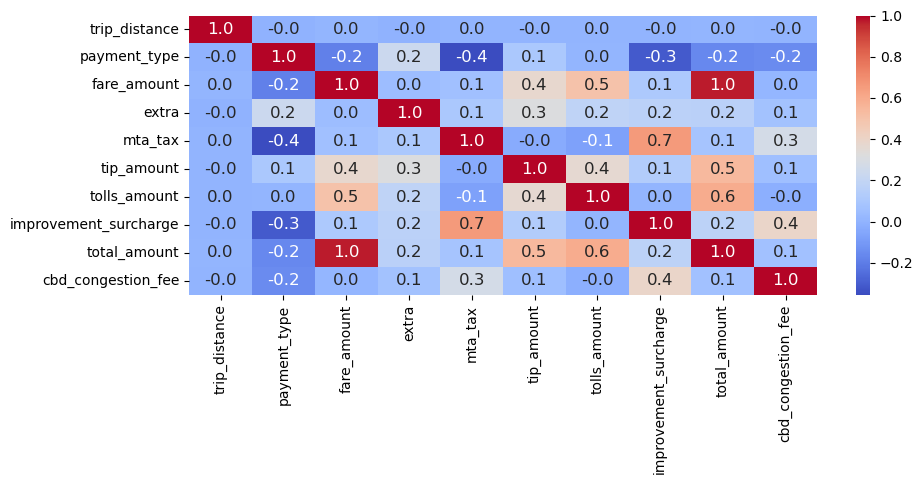

In [387]:
corr = df_numeric.corr() #how strong the relationship between each pair of data is
plt.figure(figsize=(10,5))
sns.heatmap(
    corr,
    annot=True,
    fmt = ".1f",
    cmap = "coolwarm"  #red=positive, blue=negative 
)
plt.tight_layout()
plt.show()

**Insights**
- Corr(fare_amount, total_amount) = 1.0 is a data leakage issue. total_amount = fare_amount + tip + tolls + surcharges. None can be used as a feature to predict the other.
- The current heatmap shows `trip_distance` with near-zero correlation to everything. This is not a true signal, it is the correlation values being destroyed by extreme values. Here is why:

In [388]:
inspect.signature(pd.DataFrame.corr)

<Signature (self, method: 'CorrelationMethod' = 'pearson', min_periods: 'int' = 1, numeric_only: 'bool' = False) -> 'DataFrame'>

The default correlation method in `df.corr()` is Pearson.

Pearson measures the **linear relationship** between two variables:
- r = 1 → perfect positive linear relationship
- r = 0 → no linear relationship  
- r = -1 → perfect negative linear relationship

Formula:
![Alt text](corr_formula.png)

Since the Pearson Correlation relies on the estimated means of the features, outliers will pull the mean far from the center inflating the deviation. This is why the first heatmap we plotted must exclude any outliers that are distorting the true relationship between the pair

#### Step 2: Outlier detection and Data Cleaning

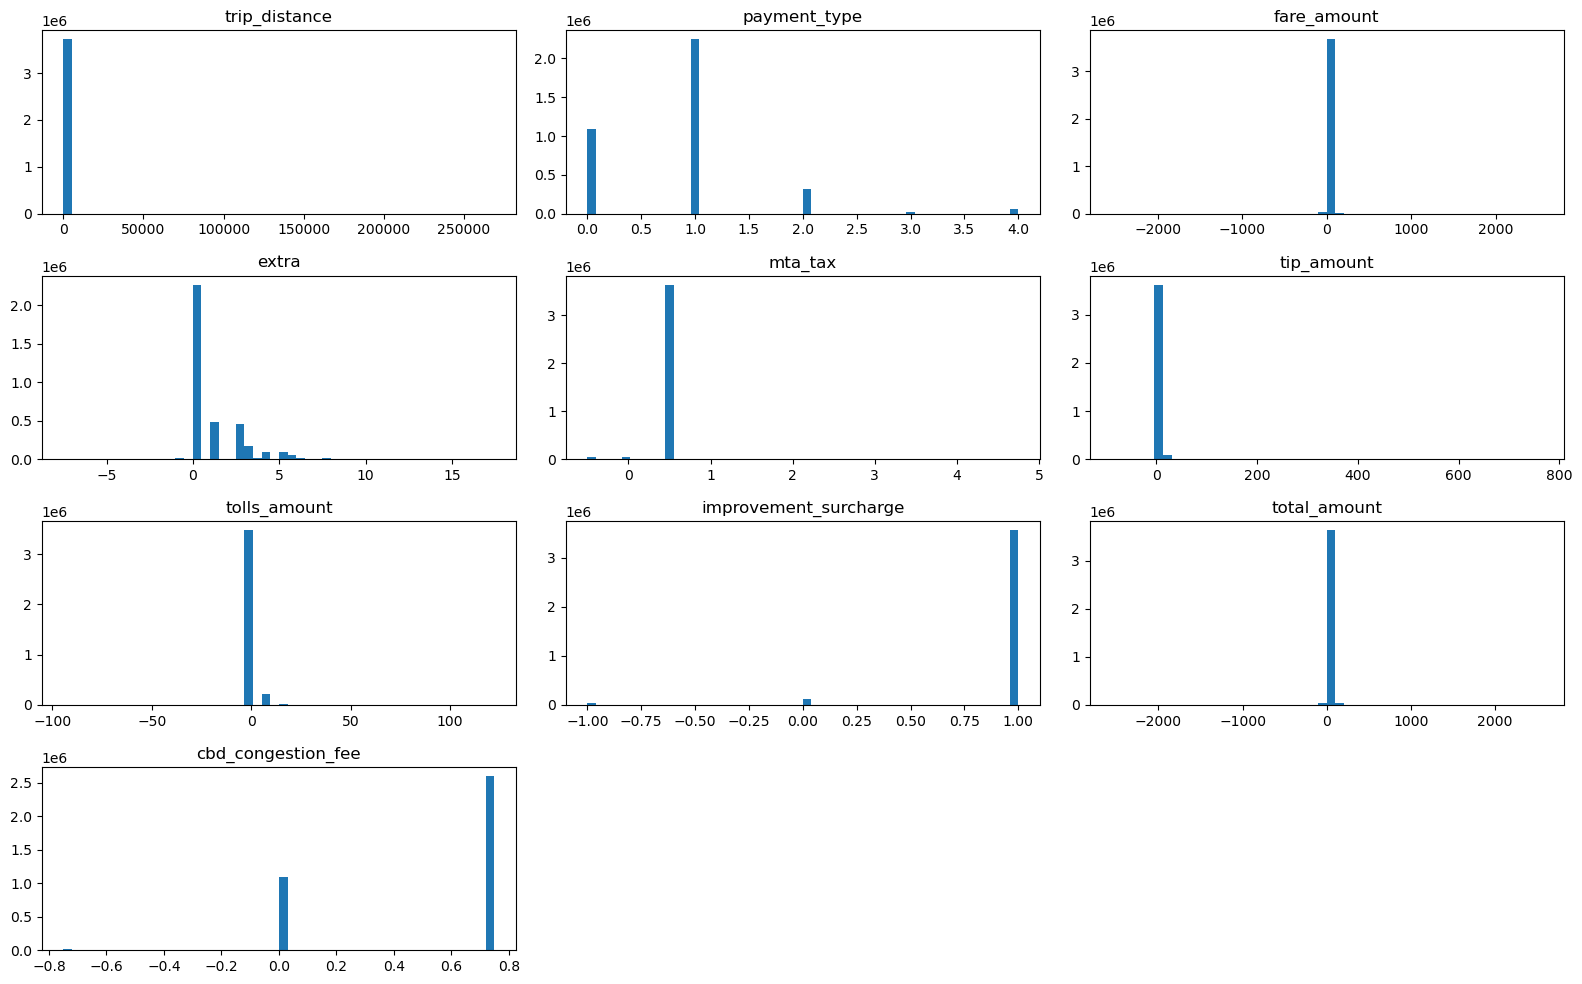

In [389]:
df_numeric.hist(grid=0, bins=50,figsize=(16, 10))
plt.tight_layout()

- Several histograms show data that is crushed into one thin spike on the left, it means a tiny number of extreme values are stretching the x-axis so far that the normal data becomes invisible. The x-axis is forced to accommodate the outliers, so everything else collapses into one bar.
- Negative amounts/fees do not exist -> Errors -> Data Cleaning needed

**Domain-Based Boundaries for Outlier Removal**

All boundaries below are derived directly from the NYC TLC official fare schedule (https://www.nyc.gov/site/tlc/passengers/taxi-fare.page).

`fare_amount`: between 3.00 and 300 dollars
The TLC sets the initial drop fee (minimum fare) at 3.00 dollars. The upper bound is
derived from the most expensive legitimate trip types defined by the TLC:

- Rate 2 (JFK flat fare): 70 dollar base + 5.00 rush hour + 1.00 improvement surcharge + 0.50 MTA surcharge + 2.50 NY State congestion surcharge + 0.75 congestion pricing
  toll + bridge/tunnel tolls + tip, totaling approximately 120 dollars
- Rate 3 (Newark): standard metered fare + 20.00 Newark surcharge + return tolls paid by passenger, totaling approximately 120 dollars
- Rate 5 (out-of-city negotiated flat fare): no TLC-defined cap — fare is mutually agreed between driver and passenger before the trip begins. This is the only legitimate scenario that justifies a generous upper bound of 300 dollars.


`trip_distance`: between 0 and 100 miles
A distance of 0 is a ghost record or meter failure.
The upper bound of 100 miles accommodates Rate 4 (Nassau/Westchester) and Rate 5 (negotiated out-of-city flat fares), which the TLC explicitly permits.

`extra`: between 0 and 5 dollars
The TLC defines the following metered extras:
- 1.00 rush hour surcharge (4pm to 8pm weekdays)
- 1.00 overnight surcharge (8pm to 6am)
- 2.50 rush hour surcharge applies to LGA trips specifically
The ceiling of 5 dollars covers all defined surcharge combinations.

`mta_tax`: exactly 0.50 dollars
Fixed MTA State Surcharge applied to all trips ending in NYC or Nassau, Suffolk, Westchester, Rockland, Dutchess, Orange or Putnam Counties. Unchanged since 2009.

`improvement_surcharge`: exactly 1.00 dollars
The current TLC Improvement Surcharge is 1.00 dollar per trip. Note: the original rate introduced in 2015 was 0.30, it has since been raised.

In [390]:
df_clean = df[
    (df['fare_amount'] >= 3.00) & (df['fare_amount'] <= 360)   & # 300 * 1.2
    (df['trip_distance'] > 0)   & (df['trip_distance'] <= 120) & # 100 * 1.2
    (df['extra'] >= 0)          & (df['extra'] <= 6)           & # 5 * 1.2
    (df['tolls_amount'] >= 0)   & (df['tolls_amount'] <= 240)  & # 200 * 1.2
    (df['mta_tax'] == 0.50)  & # fixed fee, no buffer
    (df['improvement_surcharge'] == 1.00) # fixed fee, no buffer
]

In [391]:
cols_to_exclude = [
    'tpep_pickup_datetime', 
    'tpep_dropoff_datetime',
    'VendorID',
    'PULocationID',
    'DOLocationID',
]
df_numeric_clean = df_clean.drop(columns=cols_to_exclude)

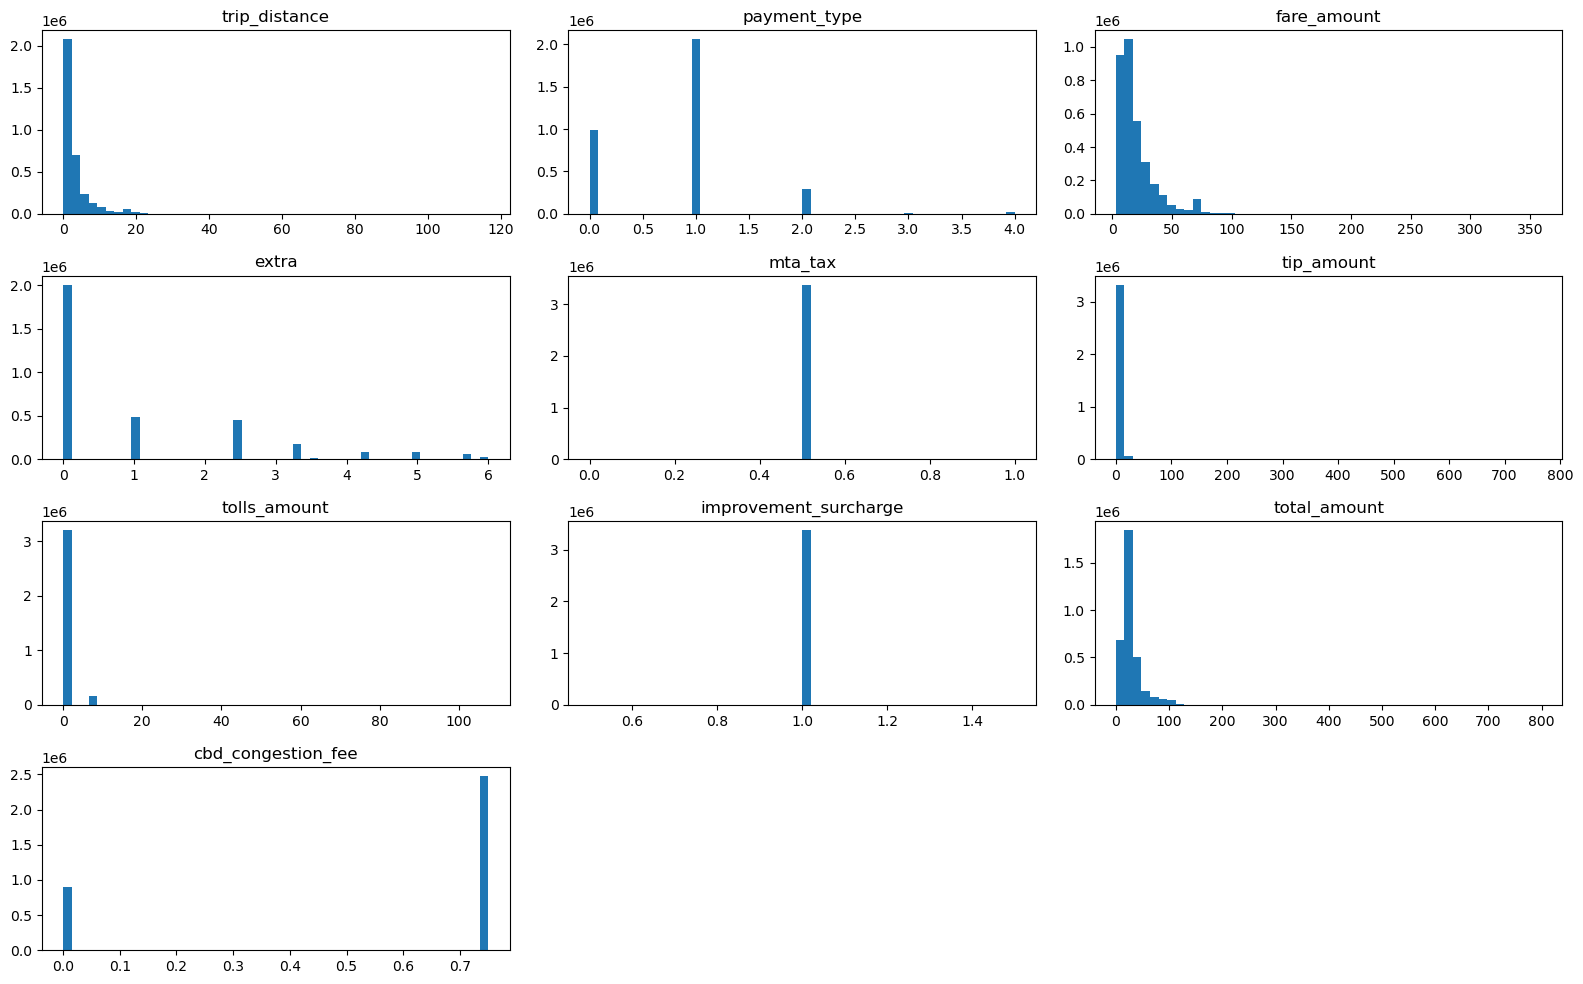

In [392]:
df_numeric_clean.hist(grid=0, bins=50,figsize=(16, 10))
plt.tight_layout()

In [393]:
#before looking at the correlation between the features, we drop the mta_tax and improvement_surcharge columns because they have a fixed values, meaning the standard deviation is not defined => correlation is not defined
df_numeric_clean = df_numeric_clean.drop(columns = ['mta_tax', 'improvement_surcharge'])

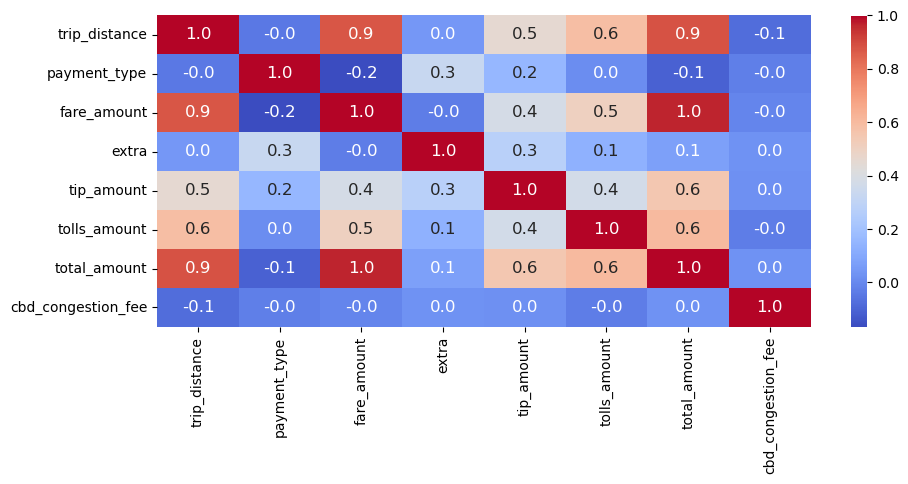

In [394]:
corr_2 = df_numeric_clean.corr() #how strong the relationship between each pair of data is
plt.figure(figsize=(10,5))
sns.heatmap(
    corr_2,
    annot=True,
    fmt = ".1f",
    cmap = "coolwarm"  #red=positive, blue=negative 
)
plt.tight_layout()
plt.show()

The strongest correlation with `fare_amount` is `total_amount` at 1.0. However this is not a meaningful finding, it is data leakage. `total_amount` is a mathematical sum that contains `fare_amount` inside it, so their near-perfect correlation is an identity,
not a learned relationship. This column must be excluded before modeling.

Removing `total_amount` from consideration, the next strongest correlation with `fare_amount` is `trip_distance` at 0.9. This is a genuine signal grounded in how NYC taxi fares are computed; the meter runs on distance, so longer trips produce higher fares by design. This is the relationship we will model.

We therefore define:
- **Target variable (y)**: `fare_amount`
- **Predictor variable (X)**: `trip_distance`

In [395]:
X = df_numeric_clean[['trip_distance']] #2D Dataframe
y = df_numeric_clean['fare_amount'] #1D Series

In [396]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [397]:
model = LinearRegression()

In [398]:
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [399]:
model.score(X_train,y_train)*100

76.6571452768135

In [400]:
model.score(X_test,y_test)*100

76.37868022240608